## Python Task - Double Quantum Dot (DQD)

This problem is inspired by a past technical interview exercise, which I reworked independently.

Consider a **Double Quantum Dot (DQD)** made of two **coupled quantum dots**, respectively **$d_1$** and **$d_2$**.

Each dot:
1. Can hold only an **integer number** of electrons;
2. Is coupled, through capacitances **$C_{d_ig_j}$**, to a gate electrode controlled by voltages **$V₁$** and **$V₂$**;
3. Is tunnel-coupled to an electron reservoir, allowing electrons to enter or exit the dot;
4. Is also tunnel-coupled to the other dot, allowing electrons to transfer between the two dots.

<img src="dqd_white.png" width="400" alt="Scheme of a DQD">


*Figure 1: Schematic representation of the Double Quantum Dot (DQD) circuit.*

### Model

The DQD is described by the following model:

1. Gate-voltage vector: $V_g = \begin{pmatrix} V_1 \\ V_2 \end{pmatrix}$
2. Charge-state vector: $N = \begin{pmatrix} n_1 \\ n_2 \end{pmatrix} ,  n_1, n_2 \in \{ 0, 1, 2, 3, \}$
3. Capacitance matrices:
    - Dot-dot capacitance matrix: $C_{dd} = \begin{pmatrix} C_{d_1d_1} & C_{d_1d_2} \\ C_{d_2d_1} & C_{d_2d_2} \end{pmatrix} $
    - Dot-gate capacitance matrix: $C_{dg} = \begin{pmatrix} C_{d_1g_1} & C_{d_1g_2} \\ C_{d_2g_1} & C_{d_2g_2} \end{pmatrix} $

The electrostatic energy is modeled using the constant-interaction approximation, expressed in matrix form.

The electrostatic energy of a charge configuration N is:
$E(N, V_g) = \frac{1}{2}(N - C_{dg}V{g})^T C_{dd}^{-1}(N - C_{dg}V{g})$.


### Goals

Given the matrices $C_{dd}$ and $C_{dg}$ and the gate voltages $V_1$ and $V_2$:

1. **Energy calculation:** compute $E(N, V_g)$ for every $(V_1, V_2)$ point on the grid and 
   for all 16 charge configurations $(n_1, n_2)$;
2. **Ground-state determination:** for each $(V_1, V_2)$, identify the charge configuration 
   that minimises $E(N, V_g)$;
3. **Visualisation:** produce a heatmap over the $(V_1, V_2)$ plane, where the colour encodes 
   the ground-state charge configuration at each point (the lowest energy charge configuration for each point $(V_1, V_2)$). This is the simulated *charge stability diagram* of the DQD;
4. **Output:** save the figure as `plot.png`.

### Parameters
*Note: the physical interpretation of the model parameters is outside the scope 
of this notebook, which focuses on the computational implementation.*

We consider a DQD with the following capacitance matrices:

$$C_{dd} = \begin{pmatrix} 9 & -2 \\ -2 & 11 \end{pmatrix}, \qquad C_{dg} = \begin{pmatrix} 1.0 & -0.05 \\ 0.1 & 1.1 \end{pmatrix}$$

Gate voltages $V_1$ and $V_2$ can vary independently over $[-1.0, 3.5]$ V with a uniform 
step of $0.01$ V. Charge occupations $n_1, n_2 \in \{0, 1, 2, 3\}$ are considered for each dot.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import json

### TASK: Given a double quantum dot system, compute the charges configuration that minimizes the energy for each pair of gate voltages.

# Defining capacitance matrix
Cdd = np.array([ [9, -2],[-2, 11]])
Cdg = np.array([ [1, -0.05], [0.1, 1.1]])
Cdd_inv = np.linalg.inv(Cdd) #computing the inverse of Cdd, we will need it to compute the energy
#Doing it outside the loop (the function) is more efficient.

# Defining gate voltages
dV = 0.01
steps = int(round((3.5 - (-1.0))/dV )) + 1
V1 = np.linspace(-1.0, 3.5, steps)
V2 = np.linspace(-1.0, 3.5, steps)

### Using meshgrid
We need to create a grid where every point is a different $V_g$ (the coordinates will be $(V_1, V_2)$), then we will loop over it (and also we need it for the plot).

For this purpose we need to use the meshgrid function.

**EXPLANATION**

(probably there is a better way to do that, sorry for the confusion :) )

By default, meshgrid returns arrays with ***row-column ordering***.

- V1_grid shape (L2, L1); each row is the same V1
- V2_grid shape (L2, L1); each column is the same V2

Remember that in meshgrid the first argument is for the columns and the second for the rows, so it is a bit counterintuitive.

To access the point (V1[i], V2[j]) we need to do V1_grid[j, i] and V2_grid[j, i].

- V1_grid[i,j] = V1[j] --> any i, the x coordinates depends on j
- V2_grid[i,j] = V2[i] --> any j, the y coordinate depends on i

**General rule:** to access the point (4,2) I have to write i = 2, j = 4.

In [2]:
# Defining grid of gate voltages

V1_grid, V2_grid = np.meshgrid(V1, V2)

# Defining charge states
n1_list = np.array([0, 1, 2, 3])
n2_list = np.array([0, 1, 2, 3])

1. **Energy calculation:** compute $E(N, V_g)$ for every $(V_1, V_2)$ point on the grid and 
   for all 16 charge configurations $(n_1, n_2)$;

For the first step we write a function that computes the energy.

Energy should be a a floating-point value for each combination of (V1, V2, n1, n2).

We will store the values of minimum energy in E, we can use an array with V1 and V2 as coordinates.

But the task is asking for the best (n1, n2) configuration, so we need to store also those values.

In [3]:
# FUNCTION TO COMPUTE ENERGY

def compute_energy(Cdd_inv, Cdg, V1, V2, n1, n2):
    Vg = np.array([V1, V2])
    N = np.array([n1, n2])
    alpha = N - Cdg @ Vg
    energy = 0.5 * alpha.T @ Cdd_inv @ alpha
    return energy

#Initialization 
E = np.zeros((len(V1), len(V2)))
n1_best = np.zeros((len(V1), len(V2)))
n2_best = np.zeros((len(V1), len(V2)))

2. **Ground-state determination:** for each $(V_1, V_2)$, identify the charge configuration 
   that minimises $E(N, V_g)$;

For this part we need to build loops that allow us to go through all the possible gate voltages and charge states.   

We first fix a point (V1, V2) and loop over all the charge states. So the loop over V1 and V2 is the outer loop.
   

In [4]:
for i in range(len(V2)):  #V2 rows /i row index (y axes)
    for j in range(len(V1)): #V1 cols /j column inded (x axes)
        # We initialize the minimum energy and n1, n2 values
        min_energy = 10000 #A large number
        n1_min = 0
        n2_min = 0
        for n1 in n1_list:
            for n2 in n2_list: 
                energy = compute_energy(Cdd_inv, Cdg, V1_grid[i, j], V2_grid[i, j], n1, n2) #Remember V1_grid[i, j] =  V1[j] and V2_grid[i, j] = V2[i]. So it is consistent with the exhcange of indexes in E, n1 and n2.
                if energy < min_energy:
                    #We update the minimum energy and the corresponding n1, n2 values
                    min_energy = energy
                    n1_min = n1
                    n2_min = n2
        
        # Outside the loop of the charges, we store Emin, n1 and n2 for this (V1, V2) point            
        E[j, i] = min_energy  
        n1_best[j, i] = n1_min  
        n2_best[j, i] = n2_min 

3. **Visualisation:** produce a heatmap over the $(V_1, V_2)$ plane, where the colour encodes 
   the ground-state charge configuration at each point (the lowest energy charge configuration for each point $(V_1, V_2)$). This is the simulated *charge stability diagram* of the DQD;

We want to plot the best charge configuration $(n_1, n_2)$ for every point $(V_1, V_2)$.

**Wrong idea:** N_best = np.array([n1_best, n2_best]) and then pcolormesh(V1_grid, V2_grid, N_best).
**BUT** pcolormesh can accept only 2D arrays, and N_best is a 3D array (2, len(V1), len(V2)).

We need to represent the *charge configuration* as a *single value*. This value needs to be unique for every combination of $(n_1, n_2)$.


We will have 16 different combinations, therefore 16 values.

We map every configuration to a number from 0 to 15, $n_1*4 + n_2$. ($n_1 + n_2$ they would not be unique)

**General rule:** For two variables $a \in (0, m)$ and $b \in (0, n)$, use $a * (n+1) + b$  to get unique values.


4. **Output:** save the figure as `plot.png`.

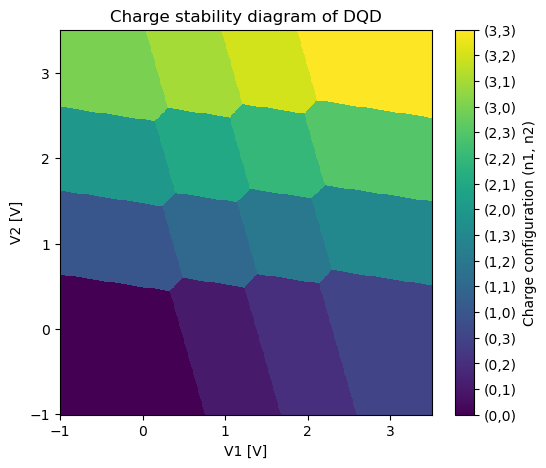

In [5]:
N_best = n1_best * 4 + n2_best  # Map configurations to unique values
plt.figure(figsize=(6,5))
plt.xlabel('V1 [V]')
plt.ylabel('V2 [V]')
plt.title('Charge stability diagram of DQD')
plt.pcolormesh(V1_grid, V2_grid, N_best)
cbar = plt.colorbar(ticks=range(16)) #Creates a colorbar with ticks at 0, 1, 2, ..., 15 (matching the 16 possible values from n1*4 + n2).
labels = [f'({n1},{n2})' for n1 in range(4) for n2 in range(4)] #Generates labels like '(0,0)', '(0,1)', ..., '(3,3)'.
cbar.ax.set_yticklabels(labels) #Sets the tick labels on the colorbar to show the actual (n1, n2) pairs.
cbar.set_label('Charge configuration (n1, n2)') #Adds a title to the colorbar.
plt.savefig('plot.png')
plt.show()

The resulting charge stability diagram shows the expected honeycomb structure typical of DQD systems.